In [6]:
cd C:\Users\HP\Downloads\crop production

C:\Users\HP\Downloads\crop production


In [7]:
pwd

'C:\\Users\\HP\\Downloads\\crop production'

In [38]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('world_food_production.csv')
df

,year,rice_production,wheat_production,vegetable_production
0,1996,568.7,578.6,542.7
1,1997,577.1,596.2,551.8
2,1998,578.8,584.8,572.8
3,1999,611.2,585.0,615.2
4,2000,598.7,588.2,686.6
5,2001,600.2,592.0,705.3
6,2002,571.1,550.1,727.3
7,2003,586.9,634.9,758.2
8,2004,607.3,626.9,768.5
9,2005,634.2,614.5,789.7


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  26 non-null     int64  
 1   rice_production       26 non-null     float64
 2   wheat_production      26 non-null     float64
 3   vegetable_production  26 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 964.0 bytes


In [42]:
df.isnull().sum().sum()

0

In [41]:
df.nunique()

year                    26
rice_production         26
wheat_production        25
vegetable_production    26
dtype: int64

In [43]:
df.corr()

,year,rice_production,wheat_production,vegetable_production
year,1.000000,0.970773,0.943181,0.992840
rice_production,0.970773,1.000000,0.938257,0.967106
wheat_production,0.943181,0.938257,1.000000,0.932812
vegetable_production,0.992840,0.967106,0.932812,1.000000


In [13]:
df.head()

,year,rice_production,wheat_production,vegetable_production
0,1996,568.7,578.6,542.7
1,1997,577.1,596.2,551.8
2,1998,578.8,584.8,572.8
3,1999,611.2,585.0,615.2
4,2000,598.7,588.2,686.6


In [14]:
x = df[['rice_production','wheat_production','vegetable_production']]
y = df['year']

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 42)
print("shape x_train :",x_train.shape)
print("shape y_train :",y_train.shape)
print("shape x_test :",x_test.shape)
print("shape y_test :",y_test.shape)

shape x_train : (19, 3)
shape y_train : (19,)
shape x_test : (7, 3)
shape y_test : (7,)


In [28]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [29]:
ridge=Ridge()
ridge.fit(x_train,y_train)

Ridge()

In [30]:
y_pred = ridge.predict(x_test)
y_pred

array([2003.65560116, 2012.8108962 , 1996.0210204 , 2018.36718569,
       2006.8163137 , 2004.62400685, 2009.66476507])

In [54]:
ridge.coef_

array([0.01688676, 0.00835248, 0.02913785])

In [55]:
ridge.intercept_

1965.7716619359626

In [35]:
mae= mean_absolute_error(y_test,y_pred)
print("Mean absolute error :",mae)

Mean absolute error : 0.5762248962637386


In [36]:
score = r2_score(y_test,y_pred)
print("R2 Score :",score)

R2 Score : 0.9876871827798847


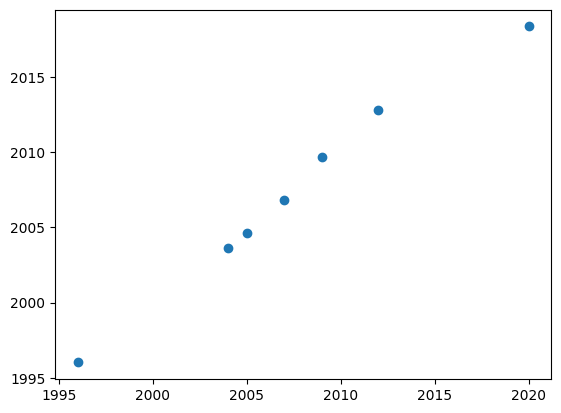

In [39]:
plt.scatter(y_test,y_pred)

<Axes: xlabel='year', ylabel='Density'>

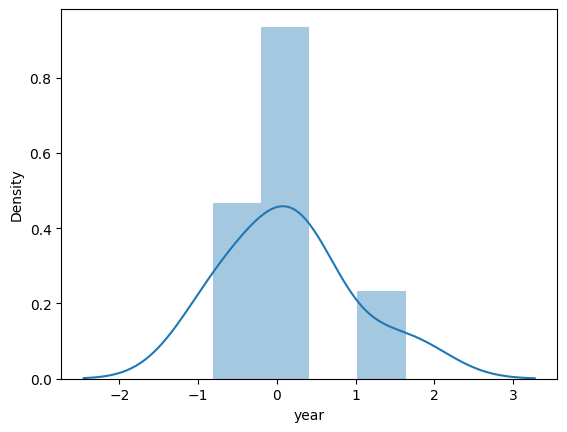

In [40]:
import seaborn as sns

sns.distplot(y_test - y_pred)

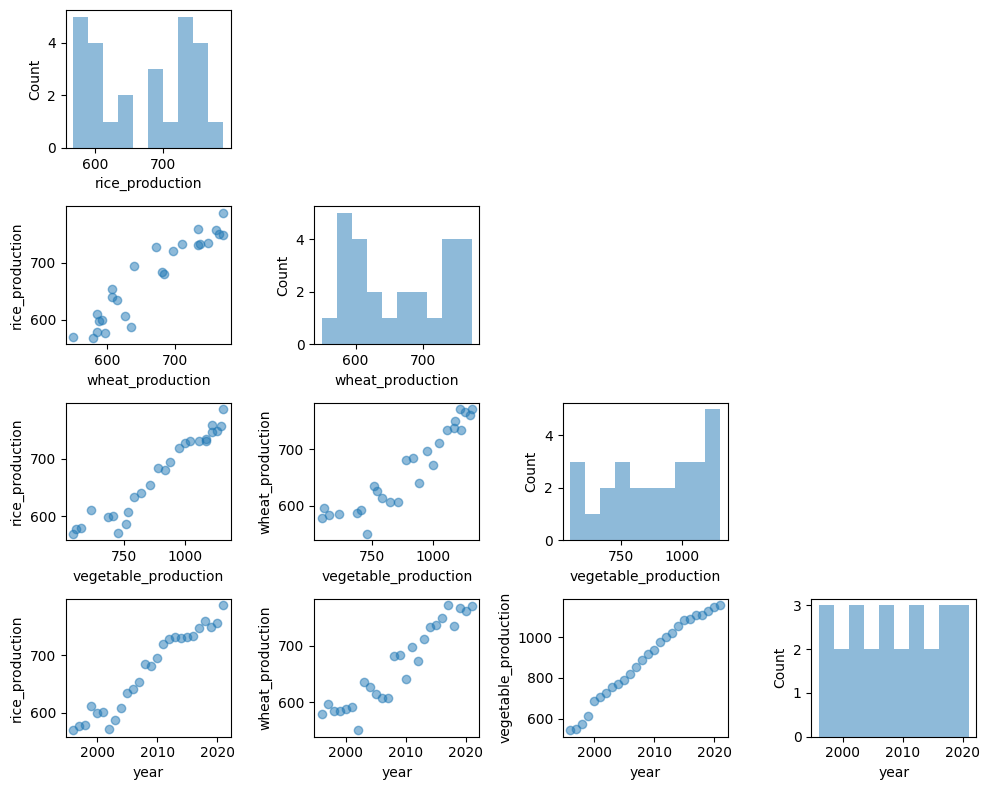

In [48]:
from mlxtend.plotting import scatterplotmatrix
cols = ['rice_production','wheat_production','vegetable_production','year']
scatterplotmatrix(df[cols].values, figsize = (10,8),names = cols, alpha=0.5)
plt.tight_layout()
plt.show()

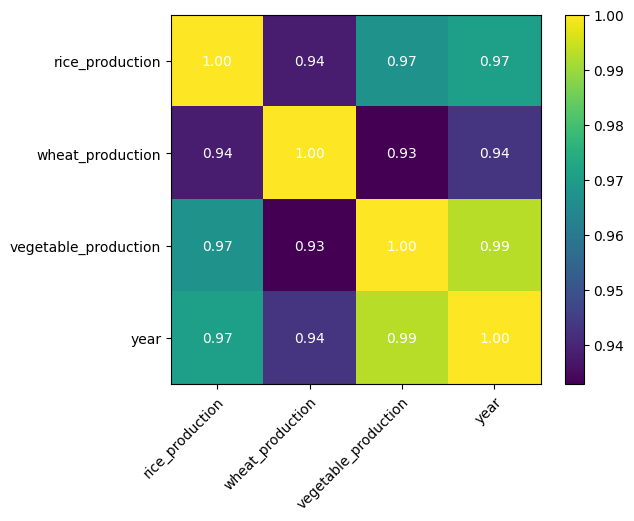

In [50]:
from mlxtend.plotting import heatmap
cm = np.corrcoef(df[cols].values.T)
hm = heatmap(cm, row_names=cols, column_names=cols)
plt.show()

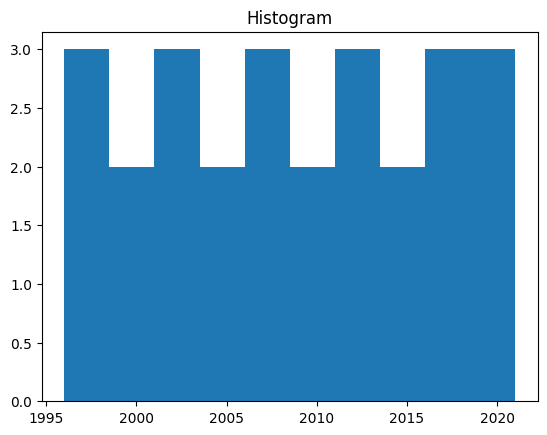

In [51]:
plt.hist(df['year'])
plt.title("Histogram")
plt.show()